In [1]:
%matplotlib inline
import os
import glob
import numpy as np
import monai.transforms as mt
import torch
from tqdm import tqdm
from time import perf_counter as time


import matplotlib.pyplot as plt

from project.dataset_iterable_optimized_release import ZarrIterableDataset, test_plot

In [2]:
# Example usage
batch_size = 4
up_factor = 2
patch_shape = (32, 32, 32)
patch_shape_hr = (64, 64, 64)

HCP_1200_train_paths = glob.glob("/work3/s173944/Python/venv_srgan/3D_datasets/datasets/HCP_1200/ome/train/*.zarr")
HCP_1200_test_paths = glob.glob("/work3/s173944/Python/venv_srgan/3D_datasets/datasets/HCP_1200/ome/test/*.zarr")

IXI_train_paths = glob.glob("./work3/s173944/Python/venv_srgan/3D_datasets/datasets/IXI/ome/train/*.zarr")
IXI_test_paths = glob.glob("/work3/s173944/Python/venv_srgan/3D_datasets/datasets/IXI/ome/test/*.zarr")

dataset_dict = {
    "HCP_1200": {
        "paths": HCP_1200_train_paths,
        "group_pairs": {
            "4": [{"H": "HR/0", "L": "HR/2"}],  # {"H": "HR/1", "L": "HR/3"}
            "2": [{"H": "HR/0", "L": "HR/1"}],  # {"H": "HR/1", "L": "HR/3"}
            "1": [{"H": "HR/0", "L": "HR/0"}],
        },
        "sampling_weight": 1,
        "store_type": "DirectoryStore"
    },
    "IXI": {
        "paths": IXI_train_paths,
        "group_pairs": {
            "4": [{"H": "HR/0", "L": "HR/2"}],  # {"H": "HR/1", "L": "HR/3"}
            "2": [{"H": "HR/0", "L": "HR/1"}],  # {"H": "HR/1", "L": "HR/3"}
            "1": [{"H": "HR/0", "L": "HR/0"}],
        },
        "sampling_weight": 1,
        "store_type": "DirectoryStore"
    }
}

Epoch 1/10


Reconstructing patches
:   0%|                          | 0/250 [00:00<?, ?it/s]

Started Producer with 4 worker(s)
Started Producer with 4 worker(s) 50% full...
Started Producer with 4 worker(s) 50% full...
Started Producer with 4 worker(s) 50% full...
Waiting for producer queues to be 50% full...

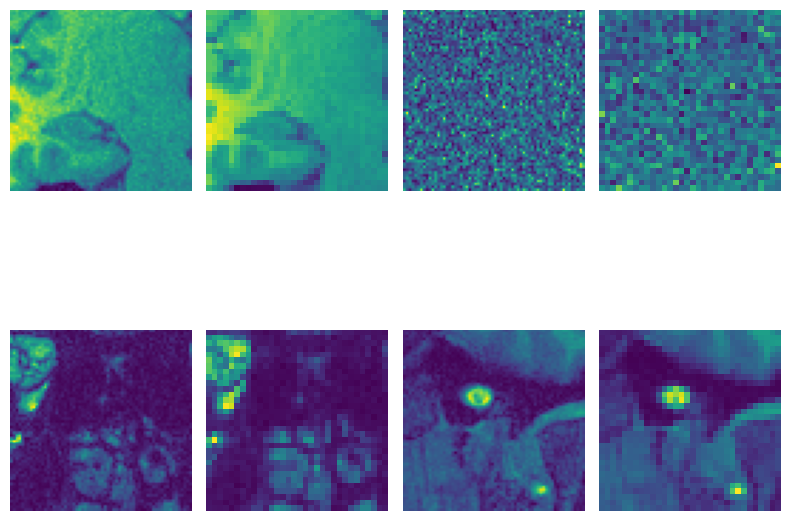

Reconstructing patches
Reconstructing patches   | 1/250 [00:07<31:11,  7.52s/it]
: 252it [00:09, 27.56it/s]                               


Epoch 2/10


Reconstructing patches
Reconstructing patches           | 0/250 [00:00<?, ?it/s]
Reconstructing patches | 168/250 [00:02<00:00, 82.91it/s]
: 252it [00:02, 95.56it/s]                               


Epoch 3/10


Reconstructing patches
Reconstructing patches           | 0/250 [00:00<?, ?it/s]
Reconstructing patches | 162/250 [00:02<00:01, 80.40it/s]
: 252it [00:03, 81.98it/s]                               


...

Epoch 9/10


Reconstructing patches
Reconstructing patches           | 0/250 [00:00<?, ?it/s]
Reconstructing patches  | 86/250 [00:02<00:03, 41.05it/s]
Reconstructing patches | 174/250 [00:04<00:01, 42.45it/s]
: 252it [00:05, 42.87it/s]                               


Epoch 10/10


Reconstructing patches
Reconstructing patches           | 0/250 [00:00<?, ?it/s]
Reconstructing patches  | 36/250 [00:02<00:11, 17.95it/s]
Reconstructing patches | 142/250 [00:04<00:02, 38.40it/s]
Reconstructing patches | 219/250 [00:06<00:00, 37.04it/s]
: 252it [00:07, 34.95it/s]                               

Time taken 51.00077638402581 sec.
Time taken per patch 0.005100077638402581 sec. (average)
Loaded 10000 items from Zarr dataset.


In [4]:

if __name__ ==  '__main__':

    seed = 8884
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Define patch transforms
    patch_transform = mt.Compose([
        mt.Identityd(keys=['H', 'L'], allow_missing_keys=True),
        mt.EnsureChannelFirstd(keys=['H', 'L'], channel_dim='no_channel'),
        # mt.SignalFillEmptyd(keys=['H', 'L'], replacement=0),  # Remove any NaNs
    ])

    num_samples = 1000
    
    dataset = ZarrIterableDataset(dataset_dict,
                                  patch_shape,
                                  patch_shape_hr,
                                  patch_transform,
                                  up_factor=up_factor,
                                  num_workers=4,
                                  queue_size=128,
                                  store_type='DirectoryStore',
                                  num_samples=num_samples,
                                  sampling_method='random'  # 'random' or 'in_chunk'
                                  )

    num_workers = 4
    persistent_workers = True if num_workers > 0 else False
    dataloader = torch.utils.data.DataLoader(dataset,
                                            batch_size=batch_size,
                                            shuffle=False,
                                            num_workers=num_workers,
                                            pin_memory=False,
                                            persistent_workers=persistent_workers)

    no_epochs = 10
    plot_counter = 0
    plot_interval = 100000
    start_time = time()
    for i in range(no_epochs):
        print(f"Epoch {i + 1}/{no_epochs}")
        for batch in tqdm(dataloader, desc='Reconstructing patches\n', mininterval=2):
            # for batch in dataloader:
            pass
            # sleep(0.1)  # Assuming some processing time
            # print("Loaded batch...")
            # for key in batch.keys():
            #     print(f"Key: {key}, Shape: {batch[key].shape}")
            if plot_counter % plot_interval == 0:
                test_plot(batch)
            plot_counter += 1


    time_elapsed = time() - start_time
    print(f"Time taken {time_elapsed} sec.")
    print(f"Time taken per patch {time_elapsed / (no_epochs * num_samples)} sec. (average)")

    print(f"Loaded {len(dataset)*no_epochs} items from Zarr dataset.")